## K-Means


In [1]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
#load the dataset
df = pd.read_csv("smartphone_usage.csv")
df.head()

,User_ID,Age,Daily_Screen_Time_Hours,Social_Media_Hours,Gaming_Hours,Productivity_App_Hours,Data_Usage_GB,Battery_Drain_Percent,Apps_Installed,Notifications_Per_Day
0,1,18,8.5,4.2,2.5,1.0,12.4,85,120,210
1,2,25,5.0,1.5,0.5,3.0,6.2,55,80,95
2,3,21,9.2,5.1,3.0,0.8,14.1,92,140,260
3,4,30,4.1,1.0,0.2,4.5,5.0,48,75,70
4,5,19,7.8,3.8,2.0,1.2,11.0,80,115,190


In [3]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   User_ID                  20 non-null     int64  
 1   Age                      20 non-null     int64  
 2   Daily_Screen_Time_Hours  20 non-null     float64
 3   Social_Media_Hours       20 non-null     float64
 4   Gaming_Hours             20 non-null     float64
 5   Productivity_App_Hours   20 non-null     float64
 6   Data_Usage_GB            20 non-null     float64
 7   Battery_Drain_Percent    20 non-null     int64  
 8   Apps_Installed           20 non-null     int64  
 9   Notifications_Per_Day    20 non-null     int64  
dtypes: float64(5), int64(5)
memory usage: 1.7 KB
None


In [4]:
X = df.drop("User_ID", axis=1)

In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [26]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X)

c:\Users\tanushka reddy\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [27]:
df["Cluster"] = clusters

In [28]:
print(df["Cluster"].value_counts())

Cluster
1    11
0     5
2     4
Name: count, dtype: int64


In [29]:
score = silhouette_score(X, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.5412815334533068


In [30]:
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X)

In [31]:
pca_df = pd.DataFrame(
    data=pca_features,
    columns=["PCA1", "PCA2"]
)
pca_df["Cluster"] = clusters

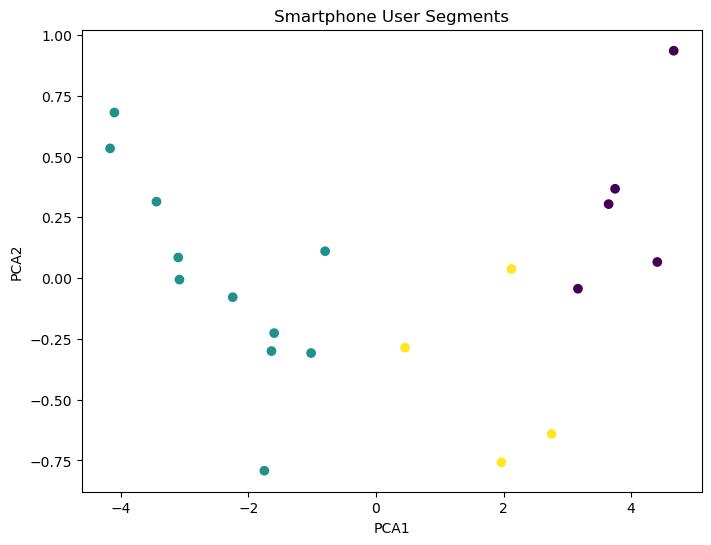

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PCA1"],
    pca_df["PCA2"],
    c=pca_df["Cluster"]
)

plt.title("Smartphone User Segments")
plt.xlabel("PCA1")
plt.ylabel("PCA2")

plt.show()